h = 0.01
Pointwise error: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0
----------------------------------------
h = 0.06
Pointwise error: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00951235 0.00883622 0.00818748 0.00756906 0.006982

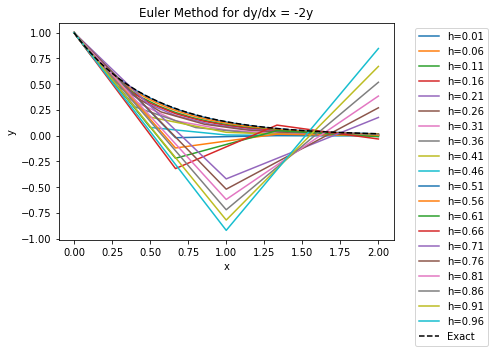

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Exact solution
def exact(x):
    return np.exp(-2 * x)

# Function dy/dx = -2y
def f(x, y):
    return -2 * y

# Step sizes
h_values = np.arange(0.01, 1.01, 0.05)

# Store baseline (h = 0.01)
baseline_y = None
baseline_x = None

plt.figure()

for h in h_values:
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    # Euler method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Save baseline
    if np.isclose(h, 0.01):
        baseline_y = y_values.copy()
        baseline_x = x_values.copy()

    # Interpolate baseline to compare grids
    if baseline_y is not None:
        baseline_interp = np.interp(x_values, baseline_x, baseline_y)
        pointwise_error = np.abs(y_values - baseline_interp)
        total_error = np.sum(pointwise_error)

        print(f"h = {h:.2f}")
        print("Pointwise error:", pointwise_error)
        print("Total accumulated error:", total_error)
        print("-" * 40)

    # Plot each run
    plt.plot(x_values, y_values, label=f"h={h:.2f}")

# Plot exact solution
x_exact = np.linspace(0, 2, 200)
plt.plot(x_exact, exact(x_exact), 'k--', label="Exact")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler Method for dy/dx = -2y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()